## Physics Informed Neural Networks to Approximate Solution of PDEs

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import torch
from torch.utils.data import DataLoader
from Common import NeuralNet, MultiVariatePoly
import time
torch.autograd.set_detect_anomaly(True)
torch.manual_seed(128)
import pandas as pd

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# torch.set_default_device(device)

In [4]:
class Pinns:
    def __init__(self, n_int_, n_sb_, n_tb_):
        self.n_int = n_int_
        self.n_sb = n_sb_
        self.n_tb = n_tb_

        # Extrema of the solution domain (t,x) in [0,0.1]x[-1,1]
        self.domain_extrema = torch.tensor([[0, 1],  # Time dimension
                                            [0, 1]])  # Space dimension

        # Number of space dimensions
        self.space_dimensions = 1

        # Parameter to balance role of data and PDE
        self.lambda_u = 10

        # F Dense NN to approximate the solution of the underlying heat equation - OP = [Ts, Tf]
        self.approximate_solution = NeuralNet(input_dimension=self.domain_extrema.shape[0], output_dimension=2,
                                              n_hidden_layers=4,
                                              neurons=20,
                                              regularization_param=0.,
                                              regularization_exp=2.,
                                              retrain_seed=42)
        '''self.approximate_solution = MultiVariatePoly(self.domain_extrema.shape[0], 3)'''

        # Generator of Sobol sequences
        self.soboleng = torch.quasirandom.SobolEngine(dimension=self.domain_extrema.shape[0])

        # Training sets S_sb, S_tb, S_int as torch dataloader
        self.training_set_sb_Ts, self.training_set_sb_Tf, self.training_set_tb, self.training_set_int = self.assemble_datasets()

    ################################################################################################
    # Function to linearly transform a tensor whose value are between 0 and 1
    # to a tensor whose values are between the domain extrema
    def convert(self, tens):
        assert (tens.shape[1] == self.domain_extrema.shape[0])
        return tens * (self.domain_extrema[:, 1] - self.domain_extrema[:, 0]) + self.domain_extrema[:, 0]

    # Initial condition to solve the heat equation u0(x)=-sin(pi x)
    def initial_condition(self, x):
        return torch.ones(x.shape)

    # Exact solution for the heat equation ut = u_xx with the IC above
    def exact_solution(self, inputs):
        t = inputs[:, 0]
        x = inputs[:, 1]

        u = -torch.exp(-np.pi ** 2 * t) * torch.sin(np.pi * x)
        return u

    ################################################################################################
    # Function returning the input-output tensor required to assemble the training set S_tb corresponding to the temporal boundary
    def add_temporal_boundary_points(self):
        t0 = self.domain_extrema[0, 0]
        input_tb = self.convert(self.soboleng.draw(self.n_tb))
        input_tb[:, 0] = torch.full(input_tb[:, 0].shape, t0)
        output_tb = self.initial_condition(input_tb[:, 1]).reshape(-1, 1)
        # output_tb_Tf = self.initial_condition(input_tb[:, 1]).reshape(-1, 1)
        return input_tb, output_tb
    # Function returning the input-output tensor required to assemble the training set S_sb corresponding to the spatial boundary
    def add_spatial_boundary_points(self):
        x0 = self.domain_extrema[1, 0]
        xL = self.domain_extrema[1, 1]

        input_sb = self.convert(self.soboleng.draw(self.n_sb))

        input_sb_0 = torch.clone(input_sb)
        input_sb_0[:, 1] = torch.full(input_sb_0[:, 1].shape, x0)

        input_sb_L = torch.clone(input_sb)
        input_sb_L[:, 1] = torch.full(input_sb_L[:, 1].shape, xL)

        output_sb_Tf_0 = (((4-1)/(1 + np.exp(-200*(input_sb_0[:,0]-0.25)))) + 1).reshape(-1,1)

        
        output_sb_Tf_L = torch.zeros((input_sb.shape[0], 1))

        output_sb_Ts_0 = torch.zeros((input_sb.shape[0], 1))
        output_sb_Ts_L = torch.zeros((input_sb.shape[0], 1))
        
        inputs = torch.cat([input_sb_0, input_sb_L], 0)
        outputs_Tf = torch.cat([output_sb_Tf_0, output_sb_Tf_L], 0)
        outputs_Ts = torch.cat([output_sb_Ts_0, output_sb_Ts_L], 0)

        return inputs, outputs_Ts, outputs_Tf

    #  Function returning the input-output tensor required to assemble the training set S_int corresponding to the interior domain where the PDE is enforced
    def add_interior_points(self):
        input_int = self.convert(self.soboleng.draw(self.n_int))
        output_int = torch.zeros((input_int.shape[0], 1))
        # output_int_Tf = torch.zeros((input_int.shape[0], 1))
        return input_int, output_int

    # Function returning the training sets S_sb, S_tb, S_int as dataloader
    def assemble_datasets(self):
        input_sb, output_sb_Ts, output_sb_Tf  = self.add_spatial_boundary_points()   # S_sb
        input_tb, output_tb = self.add_temporal_boundary_points()  # S_tb
        input_int, output_int = self.add_interior_points()         # S_int

        training_set_sb_Ts = DataLoader(torch.utils.data.TensorDataset(input_sb, output_sb_Ts), batch_size=2*self.space_dimensions*self.n_sb, shuffle=False)
        training_set_sb_Tf = DataLoader(torch.utils.data.TensorDataset(input_sb, output_sb_Tf), batch_size=2*self.space_dimensions*self.n_sb, shuffle=False)
        training_set_tb = DataLoader(torch.utils.data.TensorDataset(input_tb, output_tb), batch_size=self.n_tb, shuffle=False)
        training_set_int = DataLoader(torch.utils.data.TensorDataset(input_int, output_int), batch_size=self.n_int, shuffle=False)

        return training_set_sb_Ts, training_set_sb_Tf, training_set_tb, training_set_int

    ################################################################################################
    # Function to compute the terms required in the definition of the TEMPORAL boundary residual
    def apply_initial_condition(self, input_tb):
        u_pred_tb = self.approximate_solution(input_tb)
        return u_pred_tb

    # Function to compute the terms required in the definition of the SPATIAL boundary residual
    def apply_boundary_conditions(self, input_sb):
        u_pred_sb = self.approximate_solution(input_sb)

        return u_pred_sb

    # Function to compute the PDE residuals
    def compute_pde_residual(self, input_int):
        input_int.requires_grad = True
        u = self.approximate_solution(input_int)
        Ts = u[:,0]
        Tf = u[:,1]
        # grad compute the gradient of a "SCALAR" function L with respect to some input nxm TENSOR Z=[[x1, y1],[x2,y2],[x3,y3],...,[xn,yn]], m=2
        # it returns grad_L = [[dL/dx1, dL/dy1],[dL/dx2, dL/dy2],[dL/dx3, dL/dy3],...,[dL/dxn, dL/dyn]]
        # Note: pytorch considers a tensor [u1, u2,u3, ... ,un] a vectorial function
        # whereas sum_u = u1 + u2 + u3 + u4 + ... + un as a "scalar" one

        # In our case ui = u(xi), therefore the line below returns:
        # grad_u = [[dsum_u/dx1, dsum_u/dy1],[dsum_u/dx2, dsum_u/dy2],[dsum_u/dx3, dL/dy3],...,[dsum_u/dxm, dsum_u/dyn]]
        # and dsum_u/dxi = d(u1 + u2 + u3 + u4 + ... + un)/dxi = d(u(x1) + u(x2) u3(x3) + u4(x4) + ... + u(xn))/dxi = dui/dxi
        grad_Ts = torch.autograd.grad(Ts.sum(), input_int, create_graph=True)[0]
        grad_Ts_t = grad_Ts[:, 0]
        grad_Ts_x = grad_Ts[:, 1]
        grad_Ts_xx = torch.autograd.grad(grad_Ts_x.sum(), input_int, create_graph=True)[0][:, 1]

        # grad_u_sq_x = torch.autograd.grad(u_sq.sum(), input_int, create_graph=True)[0][:,1]

        grad_Tf = torch.autograd.grad(u.sum(), input_int, create_graph=True)[0]
        grad_Tf_t = grad_Tf[:, 0]
        grad_Tf_x = grad_Tf[:, 1]
        grad_Tf_xx = torch.autograd.grad(grad_Tf_x.sum(), input_int, create_graph=True)[0][:, 1]


        residual1 = (grad_Tf_t) + (1 * grad_Tf_x) - 0.05 * (grad_Tf_xx) + 5 * (Tf - Ts)
        residual2 = (grad_Ts_t) - 0.08 * (grad_Ts_xx) - 6 * (Tf - Ts) 
        residual1 + residual2

        return residual1.reshape(-1, ), residual2.reshape(-1, )

    # Function to compute the total loss (weighted sum of spatial boundary loss, temporal boundary loss and interior loss)
    def compute_loss(self, inp_train_sb,  u_train_sb_Ts, u_train_sb_Tf, inp_train_tb, u_train_tb_Ts, u_train_tb_Tf, inp_train_int, verbose=True):
        inp_train_sb.requires_grad = True
        # print(" inside compu_loss u_train_sb_Tf_0 = " + str(u_train_sb_Tf_0.shape))
        u_pred_sb = self.apply_boundary_conditions(inp_train_sb)
        # print('comp loss u_pred_sb_0 = ' + str(u_pred_sb_0.shape))
        u_pred_sb_Ts = u_pred_sb[:,0]
        u_pred_sb_Tf = u_pred_sb[:,1]
        
        sb_half = int(u_pred_sb_Ts.shape[0]/2)
        # print(type(sb_half))
        
        grad_u_pred_sb_Ts = torch.autograd.grad(u_pred_sb_Ts.sum(), inp_train_sb, create_graph=True)[0]
       
        grad_u_pred_sb_Tf = torch.autograd.grad(u_pred_sb_Tf.sum(), inp_train_sb, create_graph=True)[0]

        u_pred_tb = self.apply_initial_condition(inp_train_tb)
        u_pred_tb_Ts = u_pred_tb[:,0]
        u_pred_tb_Tf = u_pred_tb[:,1]

        # assert (u_pred_tb_Ts.shape[1] == u_train_tb_Ts.shape[1])
        # assert (u_pred_tb_Tf.shape[1] == u_train_tb_Tf.shape[1])


        r_int1, r_int2 = self.compute_pde_residual(inp_train_int)
        # print('r_int1 = ' + str(r_int1.shape))
        # print('r_int2 = ' + str(r_int2.shape))
        r_sb_Ts =  (grad_u_pred_sb_Ts[:,1])
        # print('r_sb_Ts = ' + str(r_sb_Ts.shape))
        r_sb_Tf_1 = (grad_u_pred_sb_Tf[sb_half:, 1])  #The size of tensor a (2) must match the size of tensor b (64) at non-singleton dimension 1
        # print('r_sb_Tf_1 = ' + str(r_sb_Tf_1.shape))
        r_sb_Tf_2 = (u_train_sb_Tf[:sb_half,0] - u_pred_sb_Tf[:sb_half])
        
        # print('r_sb_Tf_2 = ' + str(r_sb_Tf_2.shape))
        # print('u_train_sb_Tf = ' + str(u_train_sb_Tf.shape))
        # print('u_pred_sb_Tf = ' + str(u_pred_sb_Tf.shape))
        r_sb =  torch.cat([r_sb_Ts, r_sb_Tf_1, r_sb_Tf_2], 0)
        r_tb_Ts = (u_train_tb_Ts[:,0] - u_pred_tb_Ts)
        # print('r_tb_Ts = ' + str(r_tb_Ts.shape))
        # print('u_train_tb_Ts = ' + str(u_train_tb_Ts.shape))
        # print('u_pred_tb_Ts = ' + str(u_pred_tb_Ts.shape))
        r_tb_Tf = (u_train_tb_Tf[:,0] - u_pred_tb_Tf)
        # print('r_tb_Ts = ' + str(r_tb_Ts.shape))
        # print('u_train_tb_Tf = ' + str(u_train_tb_Tf.shape))
        # print('u_pred_tb_Tf = ' + str(u_pred_tb_Tf.shape))
        r_tb = torch.cat([r_tb_Ts, r_tb_Tf], 0)

        loss_sb = torch.mean(abs(r_sb) ** 2)        
        loss_tb = torch.mean(abs(r_tb) ** 2)
        loss_int_1 = torch.mean(abs(r_int1) ** 2)
        loss_int_2 = torch.mean(abs(r_int2) ** 2)
        loss_int = loss_int_2 + loss_int_1

        loss_u = loss_sb + loss_tb

        loss = torch.log10(self.lambda_u * (loss_sb + loss_tb) + loss_int)
        if verbose: print("Total loss: ", round(loss.item(), 4), "| PDE Loss: ", round(torch.log10(loss_u).item(), 4), "| Function Loss: ", round(torch.log10(loss_int).item(), 4))

        return loss

    ################################################################################################
    def fit(self, num_epochs, optimizer, verbose=True):
        history = list()

        # Loop over epochs
        for epoch in range(num_epochs):
            if verbose: print("################################ ", epoch, " ################################")

            for j, ((inp_train_sb, u_train_sb_Ts), (inp_train_sb, u_train_sb_Tf), (inp_train_tb, u_train_tb), (inp_train_int, u_train_int)) in enumerate(zip(self.training_set_sb_Ts, self.training_set_sb_Tf, self.training_set_tb, self.training_set_int)):
                def closure():
                    optimizer.zero_grad()
                    # print(" inside train u_train_sb_Tf = " + str(u_train_sb_Tf.shape))
                    loss = self.compute_loss(inp_train_sb,  u_train_sb_Ts, u_train_sb_Tf, inp_train_tb, u_train_tb, u_train_tb, inp_train_int, verbose=verbose)
                    loss.backward()

                    history.append(loss.item())
                    return loss

                optimizer.step(closure=closure)

        print('Final Loss: ', history[-1])

        return history

    ################################################################################################
    def plotting(self):
        inputs = self.soboleng.draw(100000)
        inputs = self.convert(inputs)

        output = self.approximate_solution(inputs)
        print('output.shape = ' + str(output.shape))
        output_Ts = (output[:,0]).reshape(-1, )
        output_Tf = (output[:,1]).reshape(-1, )
        # exact_output = self.exact_solution(inputs).reshape(-1, )

        fig, axs = plt.subplots(1, 2, figsize=(16, 8), dpi=150)
        im1 = axs[0].scatter(inputs[:, 1].detach(), inputs[:, 0].detach(), c=output_Tf.detach(), cmap="jet")
        axs[0].set_xlabel("x")
        axs[0].set_ylabel("t")
        plt.colorbar(im1, ax=axs[0])
        axs[0].grid(True, which="both", ls=":")
        im2 = axs[1].scatter(inputs[:, 1].detach(), inputs[:, 0].detach(), c=output_Ts.detach(), cmap="jet")
        axs[1].set_xlabel("x")
        axs[1].set_ylabel("t")
        plt.colorbar(im2, ax=axs[1])
        axs[1].grid(True, which="both", ls=":")
        axs[0].set_title("Approximate Solution - Tf")
        axs[1].set_title("Approximate Solution - Ts")

        plt.show()

        # err = (torch.mean((output - exact_output) ** 2) / torch.mean(exact_output ** 2)) ** 0.5 * 100
        # print("L2 Relative Error Norm: ", err.item(), "%")


In [5]:
# Solve the heat equation:
# u_t = u_xx, (t,x) in [0, 0.1]x[-1,1]
# with zero dirichlet BC and
# u(x,0)= -sin(pi x)

n_int = 256
n_sb = 64
n_tb = 64

pinn = Pinns(n_int, n_sb, n_tb)

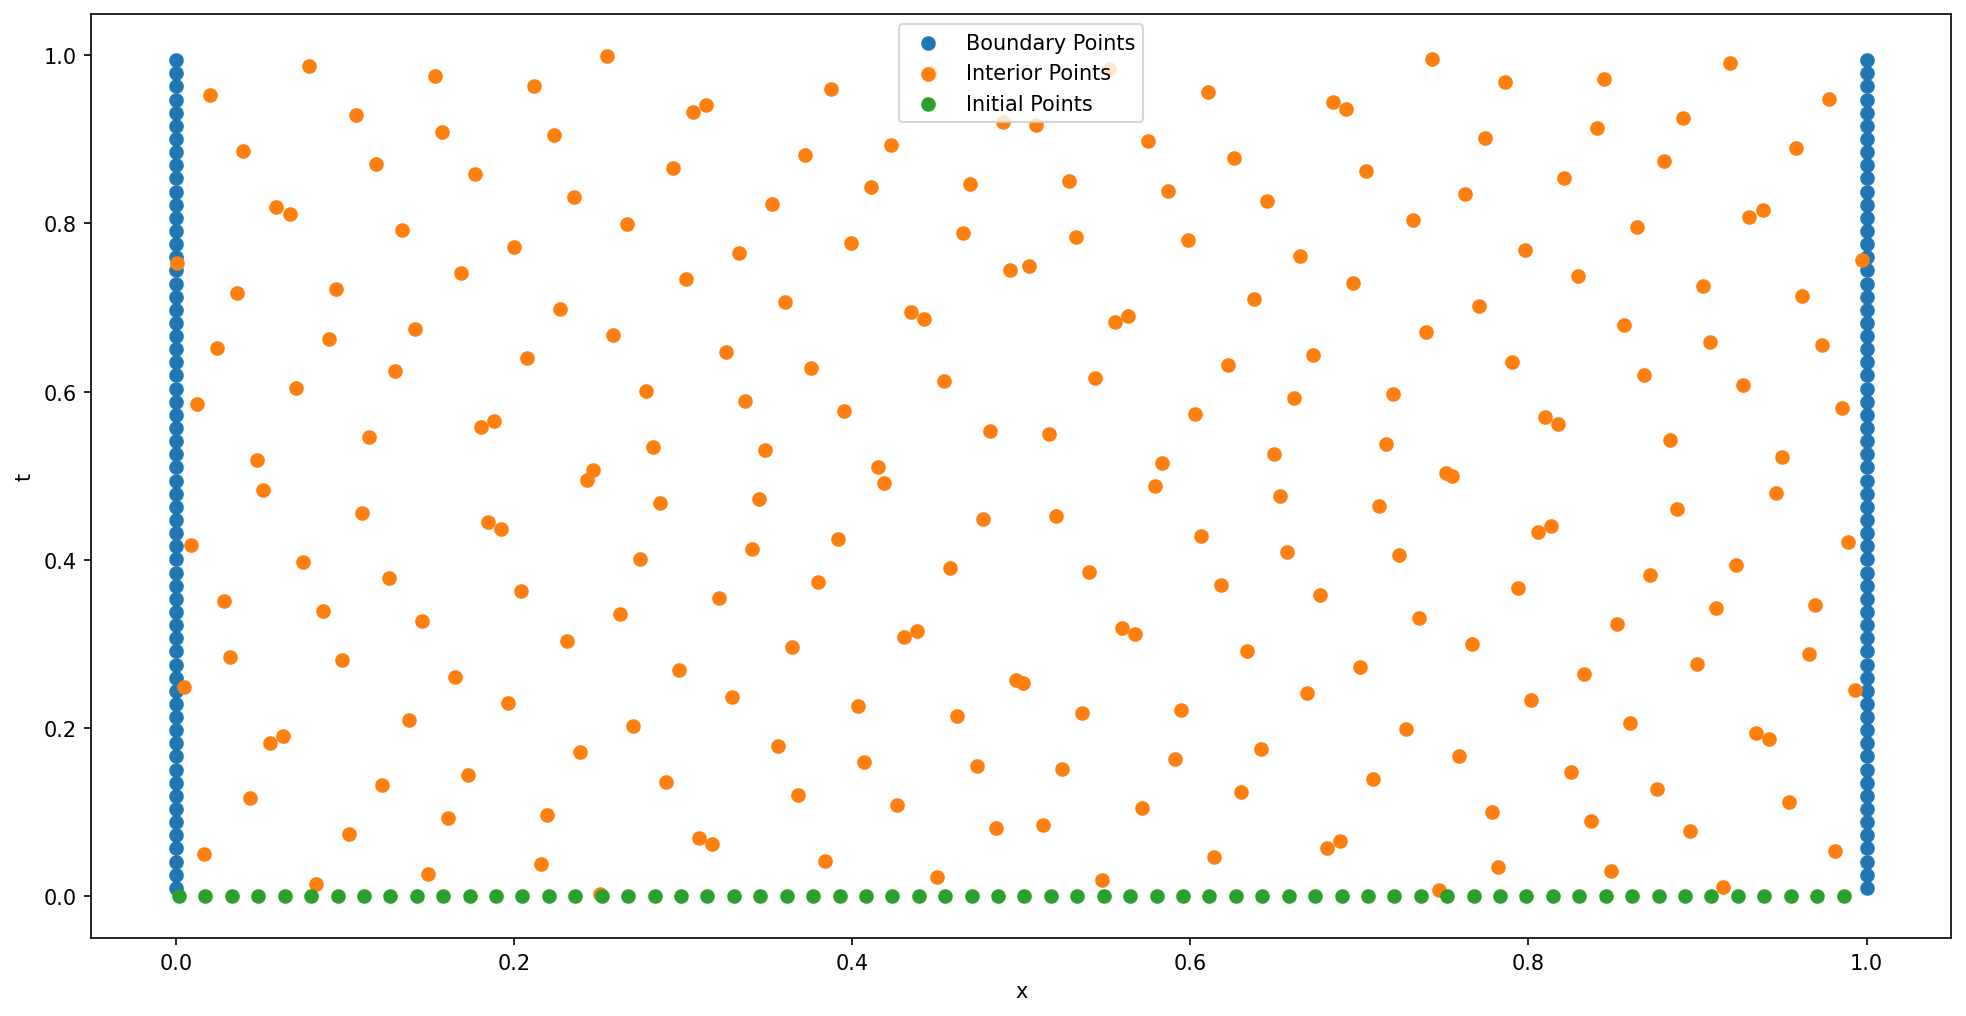

In [6]:
## Plot the input training points
input_sb_0, input_sb_L, output_sb_tf_0 = pinn.add_spatial_boundary_points()
input_tb_,  output_tb_tf  = pinn.add_temporal_boundary_points()
input_int_, output_int_ = pinn.add_interior_points()

plt.figure(figsize=(16, 8), dpi=150)
plt.scatter(input_sb_0[:, 1].detach().numpy(), input_sb_0[:, 0].detach().numpy(), label="Boundary Points")
plt.scatter(input_int_[:, 1].detach().numpy(), input_int_[:, 0].detach().numpy(), label="Interior Points")
plt.scatter(input_tb_[:, 1].detach().numpy(), input_tb_[:, 0].detach().numpy(), label="Initial Points")
plt.xlabel("x")
plt.ylabel("t")
plt.legend()
plt.show()

In [7]:
n_epochs = 1
optimizer_LBFGS = optim.LBFGS(pinn.approximate_solution.parameters(),
                              lr=float(0.5),
                              max_iter=50000,
                              max_eval=50000,
                              history_size=150,
                              line_search_fn="strong_wolfe",
                              tolerance_change=1.0 * np.finfo(float).eps)
optimizer_ADAM = optim.Adam(pinn.approximate_solution.parameters(),
                            lr=float(0.001))

################################  0  ################################
Total loss:  2.08 | PDE Loss:  0.4616 | Function Loss:  1.9604
Total loss:  1.9903 | PDE Loss:  0.4553 | Function Loss:  1.8405
Total loss:  1.824 | PDE Loss:  0.4669 | Function Loss:  1.5726
Total loss:  1.753 | PDE Loss:  0.4077 | Function Loss:  1.4922
Total loss:  1.5337 | PDE Loss:  0.1001 | Function Loss:  1.334
Total loss:  1.2892 | PDE Loss:  0.1517 | Function Loss:  0.7226
Total loss:  1.244 | PDE Loss:  0.1883 | Function Loss:  0.3245
Total loss:  1.2295 | PDE Loss:  0.1777 | Function Loss:  0.2806
Total loss:  1.2148 | PDE Loss:  0.1582 | Function Loss:  0.3013
Total loss:  1.2 | PDE Loss:  0.1317 | Function Loss:  0.3628
Total loss:  1.1865 | PDE Loss:  0.1047 | Function Loss:  0.4213
Total loss:  1.1691 | PDE Loss:  0.0723 | Function Loss:  0.4695
Total loss:  1.135 | PDE Loss:  0.0166 | Function Loss:  0.5128
Total loss:  1.0877 | PDE Loss:  -0.0435 | Function Loss:  0.5039
Total loss:  1.0316 | PDE Los

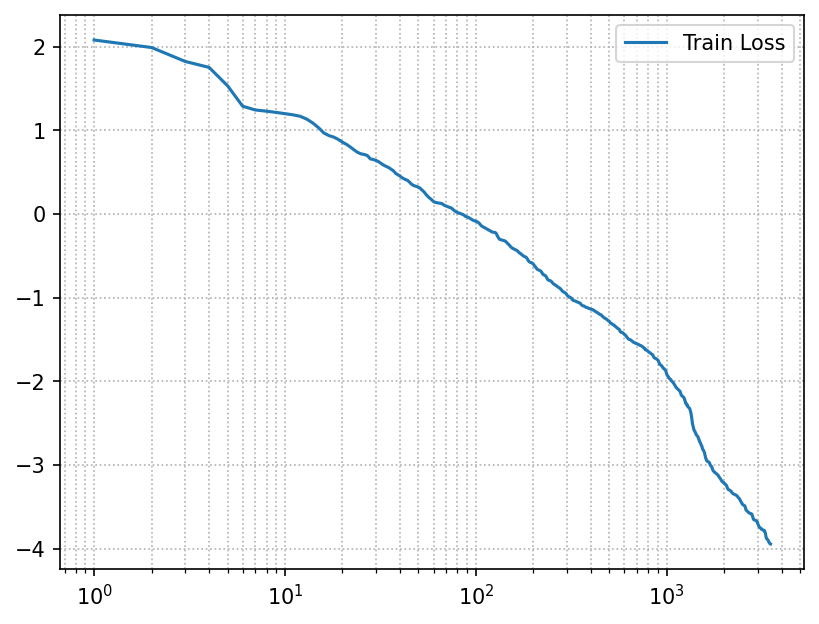

In [8]:
hist = pinn.fit(num_epochs=n_epochs,
                optimizer=optimizer_LBFGS,
                verbose=True)

plt.figure(dpi=150)
plt.grid(True, which="both", ls=":")
plt.plot(np.arange(1, len(hist) + 1), hist, label="Train Loss")
plt.xscale("log")
plt.legend()

output.shape = torch.Size([100000, 2])


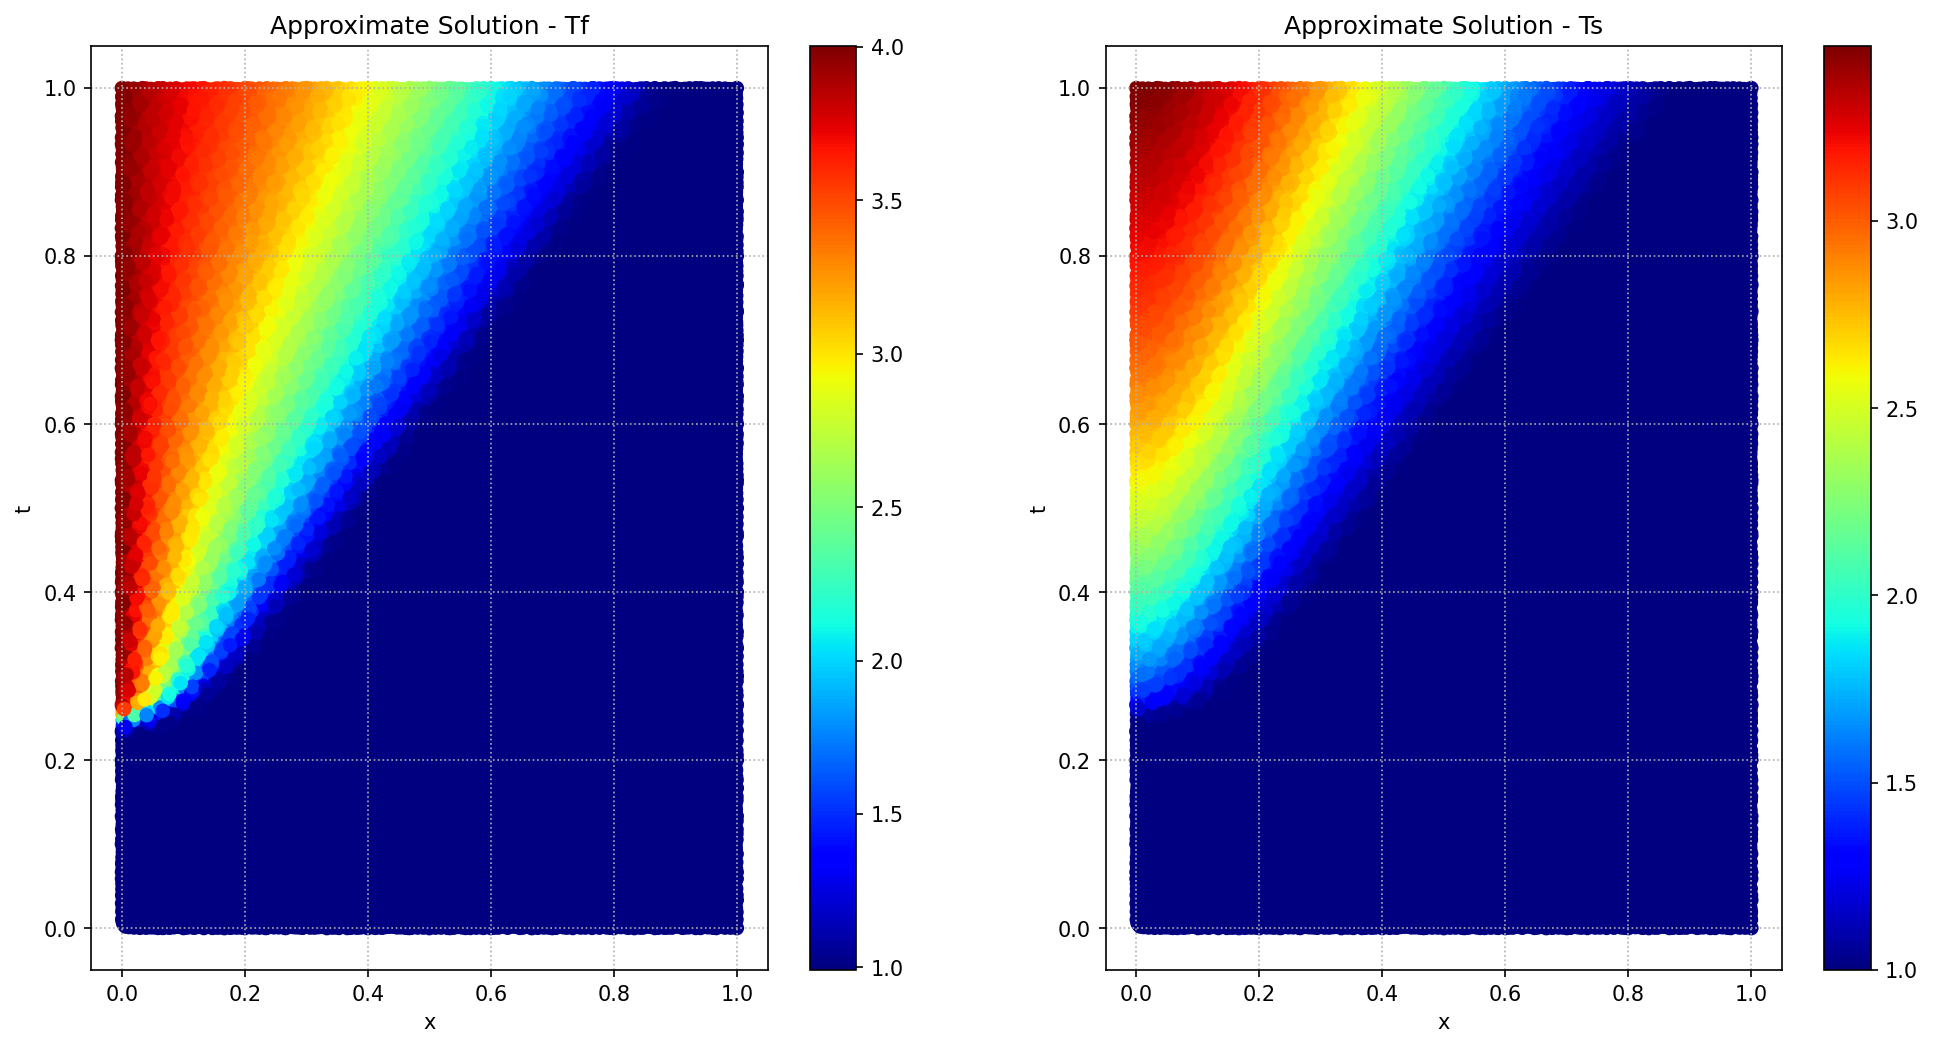

In [9]:
pinn.plotting()

In [24]:
path_to_test_file = r"K:\UZH\Spring 23\DL for SC\Task A\PA_Y23\Task1\TestingData.txt"

test_data = pd.read_csv(path_to_test_file, dtype= np.float32)
input_test = torch.tensor(test_data.values, dtype = torch.float32)

output_test = pinn.approximate_solution(input_test)
# Swap Ts and Tf since first output of NN is Ts, we need 
output_test_copy = torch.clone(output_test)
output_test[:, 0] = output_test[:, 1]
output_test[:, 1] = output_test_copy[:, 0] 
op = torch.cat([input_test, output_test], 1)
# t,x,tf,ts
print(op.shape)


torch.Size([100000, 4])


In [26]:
op[:10]

tensor([[0.6241, 0.8950, 1.0000, 1.0001],
        [0.7835, 0.7780, 0.9994, 0.9999],
        [0.3981, 0.4690, 0.9994, 1.0001],
        [0.4159, 0.9480, 1.0001, 1.0001],
        [0.9498, 0.4570, 2.5964, 2.1307],
        [0.4156, 0.4790, 0.9993, 1.0001],
        [0.7788, 0.9930, 1.0001, 1.0001],
        [0.2396, 0.7230, 1.0002, 1.0000],
        [0.3471, 0.0670, 3.0303, 1.6807],
        [0.2760, 0.4280, 1.0002, 1.0000]], grad_fn=<SliceBackward0>)

In [ ]:
# Change path
store_path = r"\TestingData_res.txt"

t_np = op.detach().numpy() #convert to Numpy array
df = pd.DataFrame(t_np) #convert to a dataframe
df.to_csv(store_path,index=False) #save to file

output.shape = torch.Size([100000, 2])


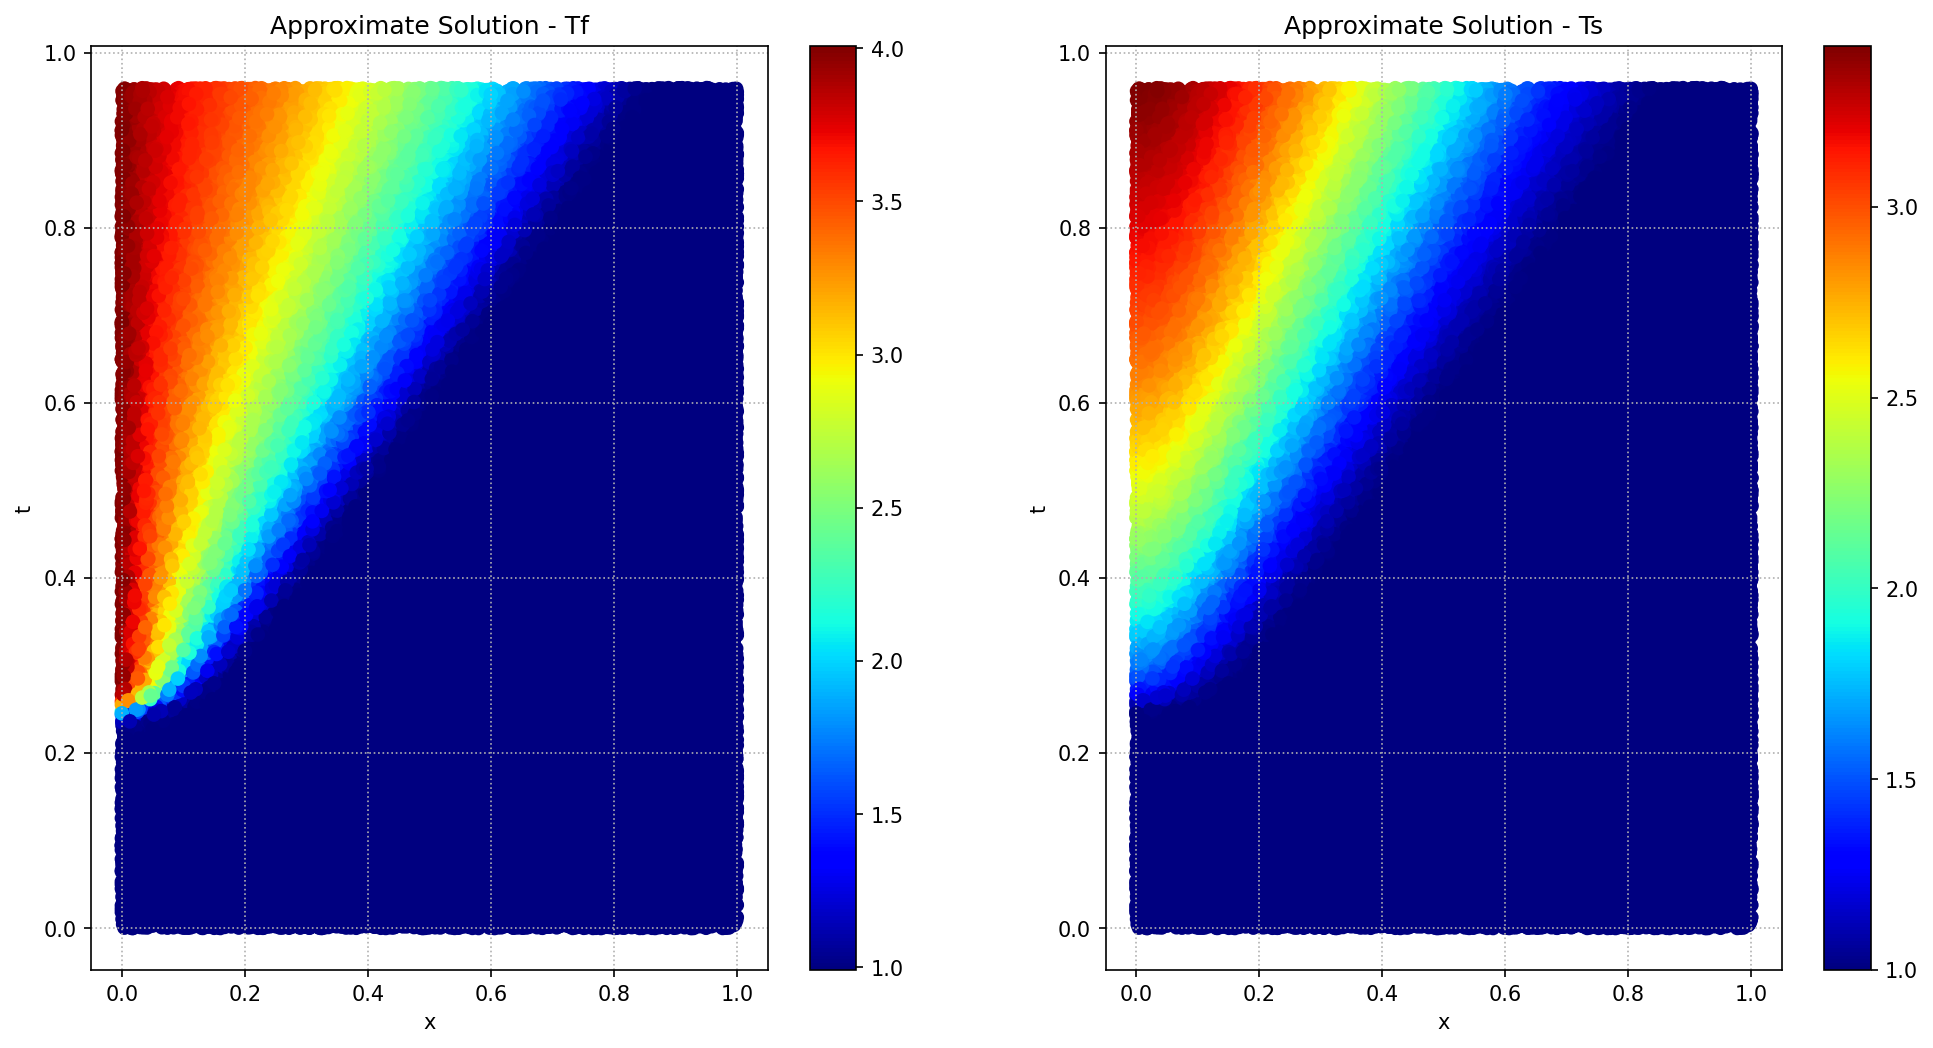

In [30]:
def plotting_test(inputs, output):
    
    print('output.shape = ' + str(output.shape))
    output_Tf = (output[:,0]).reshape(-1, )
    output_Ts = (output[:,1]).reshape(-1, )
    # exact_output = self.exact_solution(inputs).reshape(-1, )

    fig, axs = plt.subplots(1, 2, figsize=(16, 8), dpi=150)
    im1 = axs[0].scatter(inputs[:, 1].detach(), inputs[:, 0].detach(), c=output_Tf.detach(), cmap="jet")
    axs[0].set_xlabel("x")
    axs[0].set_ylabel("t")
    plt.colorbar(im1, ax=axs[0])
    axs[0].grid(True, which="both", ls=":")
    im2 = axs[1].scatter(inputs[:, 1].detach(), inputs[:, 0].detach(), c=output_Ts.detach(), cmap="jet")
    axs[1].set_xlabel("x")
    axs[1].set_ylabel("t")
    plt.colorbar(im2, ax=axs[1])
    axs[1].grid(True, which="both", ls=":")
    axs[0].set_title("Approximate Solution - Tf")
    axs[1].set_title("Approximate Solution - Ts")

    plt.show()

plotting_test(input_test, output_test)